 ### ACSC 01_preprocessing

**Purpose**  
Load and clean arithmetic catalogs, compute primary and alternative projections, fit and apply a coordinate-wise quantile alignment to the cosmic point cloud, and export derived artifacts for the TDA pipeline.

---

### Summary of steps
- **Load** Cremona and LMFDB exports (CSV) and combine with provenance.  
- **Clean** numeric fields and normalize column names to the projection API.  
- **Project** each curve using the primary rank‑normalized map and two alternatives (PTD, MCJ).  
- **Align** the arithmetic cloud to the cosmic cloud via a monotone quantile transformer fitted on the observational data.  
- **Save** projected coordinates, manifest, and small diagnostic plots for downstream TDA and reproducibility.

---

### Data sources and expected inputs
- **Arithmetic catalogs**: `acsc_validation_cremona.csv`, `acsc_validation_lmfdb.csv` (pre‑registered conductor bound `Nmax`).  
- **Cosmic catalog**: volume‑limited sample (SDSS/DESI) in comoving coordinates, CSV with at least three coordinate columns.  
- **Required invariants** per arithmetic row: **delta**, **conductor**, **rank**, **regulator**, **real_period**, **torsion_order**. Rows missing essential invariants are dropped (policy recorded).

---

### Pre-registered parameters
- **Amax** — discriminant scaling constant (set in parameters cell).  
- **Nmax** — conductor scaling constant (set in parameters cell).  
- **V0** — radial scale factor for the primary projection.  
- **TOP_SCALE** — Topological Locked Scale for later TDA (e.g., 25.0 Mpc).  
- **N_QUANTILES** — number of quantiles used by the quantile aligner (default 200).  
Record these values in `manifest.json` before running the main experiment.

---

### Reproducibility and provenance
- **Seed**: `SEED = 42` (record and save).  
- **Environment**: record Python and package versions (NumPy, Pandas, SciPy, Ripser/GUDHI).  
- **Outputs to save**: `acsc_projected_primary_aligned.csv`, `manifest.json`, diagnostic plots (`box_logdelta_by_rank.png`, `aligned_xy_sample.png`).  
- **Randomness**: set `np.random.seed(SEED)` at the top of the notebook and save the seed in the manifest.

---

### Expected outputs and artifacts
- **Derived CSV** with original invariants plus columns: `x_prim,y_prim,z_prim`, `x_ptd,y_ptd,z_ptd`, `x_mcj,y_mcj,z_mcj`, `x_aligned,y_aligned,z_aligned`.  
- **Manifest** containing row counts, parameter values, seed, and software versions.  
- **Small sample persistence check** (optional): a persistence diagram computed on a small subset to verify TDA integration.  
- **Plots**: rank distribution, boxplots of `log10|Δ|` by rank, and a scatter of aligned coordinates colored by rank.

---

### Quick checklist before running
- [ ] Confirm cosmic file path and selection cuts (volume limits).  
- [ ] Pre-register `Amax`, `Nmax`, `V0`, `TOP_SCALE`, and quantile transformer details.  
- [ ] Ensure `acsc/` modules are importable (add repo root to `PYTHONPATH` if needed).  
- [ ] Save `manifest.json` and record software versions.  
- [ ] Set `SEED` and record it in the manifest.

---

### Contact and notes
- **Notebook owner**: add your name and contact in the notebook metadata.  
- **Next notebook**: `02_tda_analysis.ipynb` will consume `acsc_projected_primary_aligned.csv` and run the persistence and null‑model experiments.


In [7]:
# Reproducibility and environment
import sys, os
REPO_ROOT = os.getcwd()   # assumes notebook is in repo root; adjust if not
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print("Inserted REPO_ROOT to sys.path:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

import json
import platform
import numpy as np
import pandas as pd


REPO_ROOT = os.path.abspath("..")  # adjust if notebook lives elsewhere

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print("sys.path[0] set to:", sys.path[0])

SEED = 42
np.random.seed(SEED)

# Record versions for reproducibility
env = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
print("Environment:", json.dumps(env, indent=2))


Inserted REPO_ROOT to sys.path: /home/kepler
sys.path[0]: /home
sys.path[0] set to: /home
Environment: {
  "python": "3.12.13",
  "numpy": "1.26.4",
  "pandas": "2.3.3"
}


In [8]:
# === Pre-registered parameters (edit before running experiments) ===
Amax = 1e12
Nmax = 1e6
V0 = 1.0
TOP_SCALE = 25.0  # Mpc, Topological Locked Scale (for later)
N_QUANTILES = 200

# File paths (edit to match your repo/data layout)
ARITH_CREMONA = "acsc_validation_cremona.csv"
ARITH_LMFDB = "acsc_validation_lmfdb.csv"
COSMIC_FILE = "cosmic_volume_sample.csv"  # path to your cosmic point cloud (comoving coords)
OUT_DIR = "derived"
os.makedirs(OUT_DIR, exist_ok=True)


In [9]:
# If running in a fresh environment, you may need to pip install the requirements.
# Uncomment the next cell to install from requirements.txt in a notebook environment.
# !pip install -r requirements.txt

# Import our package modules (assumes acsc/ is on PYTHONPATH or repo root)
from acsc.projection import project as project_records
from acsc.quantile import QuantileAligner

# Optional: tda/statistics modules for quick checks
from acsc.tda_pipeline import compute_persistence
from acsc.statistics import w2_between_diagrams, empirical_p_value


In [10]:
# Robust loader: reads CSV in chunks if file is large, returns DataFrame
def load_csv_maybe_chunks(path, max_rows=None, chunksize=200_000):
    if max_rows is not None:
        return pd.read_csv(path, nrows=max_rows)
    # try reading normally; fallback to chunks if memory error
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Standard read failed ({e}), trying chunked read...")
        chunks = []
        for chunk in pd.read_csv(path, chunksize=chunksize):
            chunks.append(chunk)
        return pd.concat(chunks, ignore_index=True)

# Load arithmetic catalogs
cremona = load_csv_maybe_chunks(ARITH_CREMONA)
lmfdb = load_csv_maybe_chunks(ARITH_LMFDB)
print(f"Cremona: {len(cremona):,} rows; LMFDB: {len(lmfdb):,} rows")

# Combine and keep provenance
cremona["source"] = "cremona"
lmfdb["source"] = "lmfdb"
df = pd.concat([cremona, lmfdb], ignore_index=True)
print("Combined rows:", len(df))


Cremona: 38,042 rows; LMFDB: 64,631 rows
Combined rows: 102673


In [11]:
# Map common column names to the keys expected by acsc.projection
# Adjust these mappings to match your CSV column names.
col_map = {
    "delta": ["delta", "minimal_discriminant", "disc", "D"],
    "conductor": ["conductor", "N"],
    "rank": ["sage_rank", "rank", "algebraic_rank"],
    "regulator": ["regulator", "R"],
    "real_period": ["real_period", "omega_real", "Q"],
    "torsion_order": ["torsion_order", "torsion", "T"],
}

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Build a normalized DataFrame with required keys
records = []
missing = set()
for idx, row in df.iterrows():
    rec = {}
    for key, candidates in col_map.items():
        col = find_col(df, candidates)
        if col is None:
            missing.add(key)
            rec[key] = None
        else:
            rec[key] = row[col]
    rec["source"] = row.get("source", None)
    records.append(rec)

if missing:
    print("Warning: missing columns for keys:", missing)

# Convert to DataFrame for numeric cleaning
rec_df = pd.DataFrame(records)

# Clean numeric columns robustly
for c in ["delta", "conductor", "rank", "regulator", "real_period", "torsion_order"]:
    if c in rec_df.columns:
        rec_df[c] = pd.to_numeric(rec_df[c], errors="coerce")

# Drop rows missing essential invariants (choose policy: drop or impute)
essential = ["delta", "conductor", "rank"]
before = len(rec_df)
rec_df = rec_df.dropna(subset=essential)
after = len(rec_df)
print(f"Dropped {before-after} rows missing essential invariants; remaining {after}")


Dropped 102673 rows missing essential invariants; remaining 0


In [12]:
# Basic summaries
rec_df["log_abs_delta"] = np.log10(rec_df["delta"].abs().replace(0, np.nan)).replace(-np.inf, np.nan)
rank_counts = rec_df["rank"].value_counts().sort_index()
mean_log_delta = rec_df.groupby("rank")["log_abs_delta"].mean().round(4)

print("Rank distribution:\n", rank_counts)
print("\nMean log10|Δ| by rank:\n", mean_log_delta)


Rank distribution:
 Series([], Name: count, dtype: int64)

Mean log10|Δ| by rank:
 Series([], Name: log_abs_delta, dtype: float64)


In [13]:
# Convert DataFrame rows to dicts for projection functions
records_for_proj = rec_df.to_dict(orient="records")

# Primary projection (rank-normalized)
coords_primary = project_records(records_for_proj, method="primary", Amax=Amax, Nmax=Nmax, V0=V0)
print("Primary coords shape:", coords_primary.shape)

# Alternative projections
coords_ptd = project_records(records_for_proj, method="ptd")
coords_mcj = project_records(records_for_proj, method="mcj")

# Attach projected coords back to DataFrame (store as columns)
rec_df[["x_prim", "y_prim", "z_prim"]] = coords_primary
rec_df[["x_ptd", "y_ptd", "z_ptd"]] = coords_ptd
rec_df[["x_mcj", "y_mcj", "z_mcj"]] = coords_mcj

# Save a small sample for quick inspection
rec_df.sample(5)


Primary coords shape: (0, 3)


ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
# Load cosmic point cloud (assumed to be Nx3 comoving coordinates)
cosmic = pd.read_csv(COSMIC_FILE)
# Ensure shape (n,3)
cosmic_coords = cosmic.iloc[:, :3].to_numpy()

# Fit quantile aligner on cosmic coords and transform primary arithmetic cloud
aligner = QuantileAligner()
aligner.fit(cosmic_coords, n_quantiles=N_QUANTILES)

# Transform the primary projection
arith_primary_coords = rec_df[["x_prim", "y_prim", "z_prim"]].to_numpy()
arith_aligned = aligner.transform(arith_primary_coords)

# Save aligned coords into DataFrame
rec_df[["x_aligned", "y_aligned", "z_aligned"]] = arith_aligned
print("Aligned coords shape:", arith_aligned.shape)


In [ ]:
# Save projected coordinates and a compact manifest for downstream TDA
proj_out = os.path.join(OUT_DIR, "acsc_projected_primary_aligned.csv")
rec_df.to_csv(proj_out, index=False)
print("Saved projected coordinates to:", proj_out)

# Save a small manifest with counts and seed
manifest = {
    "rows": int(len(rec_df)),
    "seed": int(SEED),
    "Amax": Amax,
    "Nmax": Nmax,
    "V0": V0,
    "top_scale": TOP_SCALE
}
with open(os.path.join(OUT_DIR, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)
print("Saved manifest.")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# Boxplot: log|Δ| by rank
plt.figure(figsize=(8,4))
sns.boxplot(x="rank", y="log_abs_delta", data=rec_df)
plt.title("log10|Δ| by algebraic rank")
plt.savefig(os.path.join(OUT_DIR, "box_logdelta_by_rank.png"), dpi=150)
plt.show()

# Scatter: aligned coords (first 5000 points) colored by rank (for visual sanity)
sample = rec_df.sample(min(5000, len(rec_df)), random_state=SEED)
plt.figure(figsize=(6,6))
plt.scatter(sample["x_aligned"], sample["y_aligned"], c=sample["rank"], cmap="viridis", s=6, alpha=0.6)
plt.colorbar(label="rank")
plt.title("Aligned primary projection (x vs y) colored by rank (sample)")
plt.savefig(os.path.join(OUT_DIR, "aligned_xy_sample.png"), dpi=150)
plt.show()


In [ ]:
# Compute persistence for a small sample to verify pipeline integration
sample_coords = arith_aligned[:2000]  # keep small to avoid heavy compute in notebook
res = compute_persistence(sample_coords, maxdim=2, thresh=None)
# res['dgms'] contains diagrams per dimension
for k, dgm in enumerate(res.get("dgms", [])):
    print(f"Dimension {k}: {len(dgm)} features")


In [ ]:
## Next steps
- Run the full TDA pipeline on the saved `acsc_projected_primary_aligned.csv` using `acsc/tda_pipeline.py`.
- Pre-register exact choices for `Amax`, `Nmax`, `V0`, `TOP_SCALE`, quantile transformer details, and null model seeds.
- Run null models (Null-A, Null-B, Null-C) using `acsc/null_models.py` and compute W2 distributions with `acsc/statistics.py`.

## Checklist before main experiment
- [ ] Confirm `COSMIC_FILE` path and selection cuts (volume-limited sample).
- [ ] Pre-register projection parameter values and quantile transformer interpolation method.
- [ ] Save random seeds and software versions (manifest.json).
- [ ] Run ablation tests (remove Wr, remove quantile alignment) and save results.


In [24]:
# Notebook cell: reprocess without CLI
import json, re
from pathlib import Path
import pandas as pd
import numpy as np

CANONICAL = {
    "delta": ["delta", "minimal_discriminant", "disc", "D", "discriminant"],
    "conductor": ["conductor", "N", "cond", "label"],
    "rank": ["sage_rank", "rank", "algebraic_rank", "pari_analytic_rank"],
    "regulator": ["regulator", "R"],
    "real_period": ["real_period", "omega_real", "Q"],
    "torsion_order": ["torsion_order", "torsion", "T"],
}

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def extract_conductor_from_label(label):
    if pd.isna(label):
        return None
    s = str(label).strip()
    m = re.match(r"^\s*(\d+)", s)
    if m:
        return int(m.group(1))
    m = re.match(r"^(\d+)\.", s)
    if m:
        return int(m.group(1))
    return None

def normalize_and_clean_df(df):
    col_matches = {k: find_col(df, v) for k, v in CANONICAL.items()}
    out = pd.DataFrame(index=df.index)
    for key, col in col_matches.items():
        out[key] = df[col] if col is not None else np.nan
    if col_matches.get("conductor") is None and "label" in df.columns:
        out["conductor"] = df["label"].apply(extract_conductor_from_label)
    for c in ["delta","conductor","rank","regulator","real_period","torsion_order"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    for extra in ["label","source"]:
        if extra in df.columns:
            out[extra] = df[extra]
    diag = {"rows_total": int(len(df)), "col_matches": col_matches, "null_counts": out.isna().sum().to_dict()}
    return out, diag

def reprocess_file(infile, outfile, manifest_path=None):
    infile = Path(infile)
    outfile = Path(outfile)
    manifest_path = Path(manifest_path) if manifest_path else outfile.with_suffix(".manifest.json")
    df = pd.read_csv(infile)
    cleaned, diag = normalize_and_clean_df(df)
    # policy: require delta and rank; keep rows that have both
    mask_keep = cleaned["delta"].notna() & cleaned["rank"].notna()
    kept = cleaned[mask_keep].copy()
    kept.to_csv(outfile, index=False)
    manifest = {
        "input_file": str(infile),
        "output_file": str(outfile),
        "rows_input": int(len(df)),
        "rows_output": int(len(kept)),
        "diagnostics": diag,
        "drop_policy": "drop rows missing delta or rank",
    }
    manifest_path.write_text(json.dumps(manifest, indent=2))
    print(f"Wrote cleaned CSV {outfile} rows_out {len(kept)}; manifest {manifest_path}")
    return kept, manifest

# Example usage: change paths to your files
crem_in = "cremona_raw_parsed.csv"
crem_out = "acsc_validation_cremona.csv"
lmf_in  = "lmfdb_raw_parsed.csv"
lmf_out = "acsc_validation_lmfdb.csv"

# Run reprocessing
for inp, outp in [(crem_in, crem_out), (lmf_in, lmf_out)]:
    if Path(inp).exists():
        kept_df, manifest = reprocess_file(inp, outp)
        display(kept_df.head(int(3)))
    else:
        print("Input not found:", inp)


Wrote cleaned CSV acsc_validation_cremona.csv rows_out 38042; manifest acsc_validation_cremona.manifest.json


,delta,conductor,rank,regulator,real_period,torsion_order,label
0,-161051.0,11,0,NaN,NaN,NaN,11a1
1,-21952.0,14,0,NaN,NaN,NaN,14a1
2,50625.0,15,0,NaN,NaN,NaN,15a1


Wrote cleaned CSV acsc_validation_lmfdb.csv rows_out 3064705; manifest acsc_validation_lmfdb.manifest.json


,delta,conductor,rank,regulator,real_period,torsion_order,label
0,11.0,11,0,NaN,NaN,NaN,11.a1
1,161051.0,11,0,NaN,NaN,NaN,11.a2
2,11.0,11,0,NaN,NaN,NaN,11.a3


In [29]:
# Notebook cell: end-to-end small pipeline
import json, re, os
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime

# imports from your package
from acsc.projection import project as project_records

# helper functions (reprocessor + merge)
CANONICAL = {
    "delta": ["delta","minimal_discriminant","disc","D","discriminant"],
    "conductor": ["conductor","N","cond","label"],
    "rank": ["sage_rank","rank","algebraic_rank","pari_analytic_rank"],
    "regulator": ["regulator","R"],
    "real_period": ["real_period","omega_real","Q"],
    "torsion_order": ["torsion_order","torsion","T"],
}

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def extract_conductor_from_label(label):
    if pd.isna(label): return None
    s = str(label).strip()
    m = re.match(r"^\s*(\d+)", s)
    if m: return int(m.group(1))
    m = re.match(r"^(\d+)\.", s)
    if m: return int(m.group(1))
    return None

def normalize_and_clean_df(df):
    col_matches = {k: find_col(df, v) for k,v in CANONICAL.items()}
    out = pd.DataFrame(index=df.index)
    for key,col in col_matches.items():
        out[key] = df[col] if col is not None else pd.NA
    if col_matches.get("conductor") is None and "label" in df.columns:
        out["conductor"] = df["label"].apply(extract_conductor_from_label)
    for c in ["delta","conductor","rank","regulator","real_period","torsion_order"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    for extra in ["label","source"]:
        if extra in df.columns:
            out[extra] = df[extra]
    return out

def reprocess_and_merge(infile, lookup_csv, out_csv):
    df = pd.read_csv(infile)
    cleaned = normalize_and_clean_df(df)
    kept = cleaned[cleaned["delta"].notna() & cleaned["rank"].notna()].copy()
    if Path(lookup_csv).exists():
        lookup = pd.read_csv(lookup_csv)
        merged = kept.merge(lookup, on="label", how="left", suffixes=("","_lk"))
        for col in ["regulator","real_period","torsion_order","conductor"]:
            lk = col + "_lk"
            if lk in merged.columns:
                merged[col] = merged[col].fillna(merged[lk])
                merged = merged.drop(columns=[lk])
    else:
        merged = kept
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    merged.to_csv(out_csv, index=False)
    print("Wrote cleaned+merged", out_csv, "rows:", len(merged))
    return merged

# Paths (edit as needed)
lookup = "data/arith_lookup_by_label.csv"
crem_in = "cremona_raw_parsed.csv"
crem_out = "derived/acsc_projected_cremona_final.csv"

# Run reprocess+merge
df_final = reprocess_and_merge(crem_in, lookup, crem_out.replace(".csv", ".cleaned.csv"))

# Project and attach coords
records = df_final.to_dict(orient="records")
coords_primary = project_records(records, method="primary", Amax=Amax, Nmax=Nmax, V0=V0)
coords_ptd     = project_records(records, method="ptd")
coords_mcj     = project_records(records, method="mcj")
df_final[["x_prim","y_prim","z_prim"]] = coords_primary
df_final[["x_ptd","y_ptd","z_ptd"]] = coords_ptd
df_final[["x_mcj","y_mcj","z_mcj"]] = coords_mcj

# Save final derived CSV and manifest
out_csv = crem_out
df_final.to_csv(out_csv, index=False)
manifest = {
  "created_at": datetime.utcnow().isoformat() + "Z",
  "rows_output": int(len(df_final)),
  "notes": "reprocessed, merged lookup, projected"
}
Path(out_csv + ".manifest.json").write_text(json.dumps(manifest, indent=2))
print("Wrote final derived CSV and manifest:", out_csv)
display(df_final.head(int(3)))


Wrote cleaned+merged derived/acsc_projected_cremona_final.cleaned.csv rows: 38042
Wrote final derived CSV and manifest: derived/acsc_projected_cremona_final.csv


/tmp/ipykernel_7182/1112289214.py:90: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",


,delta,conductor,rank,regulator,real_period,torsion_order,label,x_prim,y_prim,z_prim,x_ptd,y_ptd,z_ptd,x_mcj,y_mcj,z_mcj
0,-161051.0,11,0,NaN,NaN,NaN,11a1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-21952.0,14,0,NaN,NaN,NaN,14a1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,50625.0,15,0,NaN,NaN,NaN,15a1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [31]:
from acsc.quantile import QuantileAligner
import numpy as np, pandas as pd

# load reference cloud (choose a representative sample or external cosmic cloud)
ref = pd.read_csv("data/cosmic_sample.csv")  # replace with your reference
ref_coords = ref[["x","y","z"]].to_numpy()

df = pd.read_csv("derived/acsc_projected_cremona_final.csv")
src_coords = df[["x_prim","y_prim","z_prim"]].to_numpy()

aligner = QuantileAligner()
aligner.fit(ref_coords, n_quantiles=200)
aligned = aligner.transform(src_coords)

df[["x_aligned","y_aligned","z_aligned"]] = aligned
df.to_csv("derived/acsc_projected_cremona_aligned.csv", index=False)
print("Wrote derived/acsc_projected_cremona_aligned.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'data/cosmic_sample.csv'

In [36]:
import importlib, inspect, sys
import acsc.projection as proj_mod
importlib.reload(proj_mod)
from acsc.projection import project as project_records

print("Using projection module:", inspect.getsourcefile(proj_mod))

# re-run projection on your cleaned records
import pandas as pd
rec_df = pd.read_csv("acsc_validation_cremona.csv")  # or the DataFrame you used
records_for_proj = rec_df.to_dict(orient="records")

coords_primary = project_records(records_for_proj, method="primary", Amax=Amax, Nmax=Nmax, V0=V0)
coords_ptd     = project_records(records_for_proj, method="ptd", Amax=Amax, Nmax=Nmax, V0=V0)
coords_mcj     = project_records(records_for_proj, method="mcj", Amax=Amax, Nmax=Nmax, V0=V0)

print("Primary coords shape:", coords_primary.shape)
print("Primary coords sample (first 5):")
print(coords_primary[:5])


Using projection module: /home/kepler/acsc/projection.py
Primary coords shape: (38042, 3)
Primary coords sample (first 5):
[[1.08259881e+11 0.00000000e+00 0.00000000e+00]
 [8.25099751e+10 3.54007399e+04 0.00000000e+00]
 [9.33066509e+10 4.55283642e+04 0.00000000e+00]
 [9.97756143e+10 6.39013534e+04 0.00000000e+00]
 [6.74789466e+10 8.02284234e+04 0.00000000e+00]]


In [37]:
import numpy as np
rec_df[["x_prim","y_prim","z_prim"]] = coords_primary
rec_df[["x_ptd","y_ptd","z_ptd"]] = coords_ptd
rec_df[["x_mcj","y_mcj","z_mcj"]] = coords_mcj

# quick sanity stats
for name in ["x_prim","y_prim","z_prim"]:
    a = rec_df[name].to_numpy()
    print(f"{name}: min {a.min():.6g}, max {a.max():.6g}, mean {a.mean():.6g}, std {a.std():.6g}")

rec_df.to_csv("derived/acsc_projected_cremona_realproj.csv", index=False)
print("Wrote derived/acsc_projected_cremona_realproj.csv")


x_prim: min 0, max 1e+12, mean 2.20288e+11, std 1.15703e+11
y_prim: min 0, max 1e+06, mean 874303, std 119240
z_prim: min 0, max 0.795167, mean 0.294401, std 0.260782
Wrote derived/acsc_projected_cremona_realproj.csv


In [38]:
import numpy as np, pandas as pd
df = pd.read_csv("derived/acsc_projected_cremona_realproj.csv")
coords = df[["x_prim","y_prim","z_prim"]].to_numpy()
# not all equal to index
print("Any coordinate equal to index sequence?", np.all(coords == np.arange(len(coords))[:,None]))
# check distributions
print("x_prim range:", coords[:,0].min(), coords[:,0].max())
print("y_prim range:", coords[:,1].min(), coords[:,1].max())
print("z_prim range:", coords[:,2].min(), coords[:,2].max())


Any coordinate equal to index sequence? False
x_prim range: 0.0 1000000000000.0
y_prim range: 0.0 1000000.0
z_prim range: 0.0 0.7951672353008665


In [40]:
# write alt_mappings.py and quantile.py into acsc/
from pathlib import Path

alt_code = r'''from typing import Sequence, Dict, Any
import numpy as np
import pandas as pd

def _safe_log10(arr, floor=1.0):
    a = np.asarray(arr, dtype=float)
    mask = ~np.isfinite(a) | (a == 0)
    out = np.empty_like(a)
    out[mask] = np.log10(float(floor))
    out[~mask] = np.log10(np.abs(a[~mask]))
    return out

def _scale(arr, lo, hi):
    a = np.asarray(arr, dtype=float)
    if a.size == 0:
        return a
    mn = np.nanmin(a); mx = np.nanmax(a)
    if not np.isfinite(mn) or not np.isfinite(mx) or mn == mx:
        return np.full_like(a, 0.5*(lo+hi))
    s = (a - mn) / (mx - mn)
    return lo + s*(hi-lo)

def _saturate(arr, v0=1.0):
    r = np.nan_to_num(np.asarray(arr, dtype=float), nan=0.0)
    mapped = np.arctan(r/float(v0)) / (0.5*np.pi)
    return np.clip(mapped, 0.0, 1.0)

def _j_to_complex(jvals):
    # Map complex or real j-invariant to two real axes: log|Re(j)| and log|Im(j)| (Im may be 0)
    j = np.asarray(jvals, dtype=complex)
    re = np.real(j)
    im = np.imag(j)
    # floor small values to avoid -inf
    re_log = _safe_log10(np.where(np.isfinite(re) & (np.abs(re)>0), re, 1.0))
    im_log = _safe_log10(np.where(np.isfinite(im) & (np.abs(im)>0), im, 1.0))
    return re_log, im_log

def _records_to_df(records):
    df = pd.DataFrame.from_records(records)
    # ensure columns exist
    for c in ["delta","conductor","rank","regulator","real_period","torsion_order","j_invariant"]:
        if c not in df.columns:
            df[c] = pd.NA
    # coerce numeric where appropriate
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce")
    df["conductor"] = pd.to_numeric(df["conductor"], errors="coerce")
    df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
    df["regulator"] = pd.to_numeric(df["regulator"], errors="coerce")
    df["real_period"] = pd.to_numeric(df["real_period"], errors="coerce")
    df["torsion_order"] = pd.to_numeric(df["torsion_order"], errors="coerce")
    return df

def map_ptd(records: Sequence[Dict[str,Any]], Amax: float=1.0, Nmax: float=1.0, V0: float=1.0):
    """
    PTD mapping:
      X = scaled log10(|delta|)
      Y = scaled log10(real_period)  (if missing, fallback to log10(1+regulator))
      Z = log(1 + torsion_order) mapped via saturating transform
    """
    df = _records_to_df(records)
    n = len(df)
    if n == 0:
        return np.zeros((0,3), dtype=float)

    # X: discriminant
    x_log = _safe_log10(df["delta"].to_numpy(), floor=1.0)
    x = _scale(x_log, 0.0, float(Amax))

    # Y: prefer real_period; fallback to regulator
    rp = df["real_period"].to_numpy()
    rp_fallback = df["regulator"].to_numpy()
    # choose rp where finite else fallback
    y_source = np.where(np.isfinite(rp), rp, np.where(np.isfinite(rp_fallback), rp_fallback, 1.0))
    y_log = _safe_log10(y_source, floor=1.0)
    y = _scale(y_log, 0.0, float(Nmax))

    # Z: torsion -> log(1+T) then saturate
    T = df["torsion_order"].to_numpy()
    T_safe = np.where(np.isfinite(T), T, 0.0)
    z_raw = np.log1p(np.abs(T_safe))
    z = _saturate(z_raw, v0=float(V0)) * float(V0)

    coords = np.vstack([x,y,z]).T
    return coords

def map_mcj(records: Sequence[Dict[str,Any]], Amax: float=1.0, Nmax: float=1.0, V0: float=1.0):
    """
    MCJ mapping:
      X = scaled log10(conductor)
      Y = scaled log|Re(j)| (from j-invariant)
      Z = scaled log|Im(j)|  (captures modular position)
    If j_invariant missing, fallback to small constant.
    """
    df = _records_to_df(records)
    n = len(df)
    if n == 0:
        return np.zeros((0,3), dtype=float)

    # X: conductor
    cond = df["conductor"].to_numpy()
    cond_safe = np.where(np.isfinite(cond) & (cond>0), cond, 1.0)
    x_log = _safe_log10(cond_safe, floor=1.0)
    x = _scale(x_log, 0.0, float(Amax))

    # j-invariant handling
    jcol = df["j_invariant"].to_numpy()
    # try to parse numeric or complex strings; if not, treat as NaN
    # assume jcol may already be numeric or complex
    try:
        j_complex = np.array([complex(v) if (v is not None and not (pd.isna(v))) else complex(1.0) for v in jcol])
    except Exception:
        # fallback: treat all as 1.0
        j_complex = np.full(n, complex(1.0))

    re_log, im_log = _j_to_complex(j_complex)
    y = _scale(re_log, 0.0, float(Nmax))
    z = _scale(im_log, 0.0, float(V0))

    coords = np.vstack([x,y,z]).T
    return coords'''
quant_code = r'''import numpy as np
import json
from pathlib import Path

class QuantileAligner:
    def __init__(self):
        self._fitted = False
        self._quantiles = None
        self._axis_maps = None

    def fit(self, ref_coords: np.ndarray, n_quantiles: int = 200):
        ref_coords = np.asarray(ref_coords, dtype=float)
        if ref_coords.ndim != 2 or ref_coords.shape[1] != 3:
            raise ValueError("ref_coords must be (n,3)")
        q = np.linspace(0.0, 1.0, n_quantiles)
        self._quantiles = q.tolist()
        self._axis_maps = []
        for axis in range(3):
            vals = ref_coords[:, axis]
            vals_sorted = np.sort(vals[~np.isnan(vals)])
            if vals_sorted.size == 0:
                self._axis_maps.append([0.0]*n_quantiles)
            else:
                # compute empirical quantiles via interpolation
                qs = np.quantile(vals_sorted, q)
                self._axis_maps.append(qs.tolist())
        self._fitted = True
        return self

    def transform(self, src_coords: np.ndarray):
        if not self._fitted:
            raise RuntimeError("QuantileAligner not fitted")
        src = np.asarray(src_coords, dtype=float)
        if src.ndim != 2 or src.shape[1] != 3:
            raise ValueError("src_coords must be (m,3)")
        out = np.empty_like(src)
        q = np.array(self._quantiles)
        for axis in range(3):
            axis_map = np.array(self._axis_maps[axis])
            # map each src value to its empirical quantile in axis_map, then map to axis_map value
            # we compute the quantile of src value relative to axis_map via linear interpolation
            # first compute CDF-like mapping by inverting axis_map
            # handle constant axis_map
            if np.allclose(axis_map, axis_map[0]):
                out[:, axis] = axis_map[0]
                continue
            # for each value, find its fractional position in axis_map
            # use np.interp: given x=src_val, xp=axis_map, fp=q
            src_vals = src[:, axis]
            # clamp src_vals to axis_map range
            minv, maxv = axis_map[0], axis_map[-1]
            src_clamped = np.clip(src_vals, minv, maxv)
            frac = np.interp(src_clamped, axis_map, q)
            # now map frac back to axis_map (identity here) — effectively we are projecting onto ref quantiles
            out[:, axis] = np.interp(frac, q, axis_map)
        return out

    def save(self, path):
        d = {"quantiles": self._quantiles, "axis_maps": self._axis_maps}
        Path(path).write_text(json.dumps(d))

    def load(self, path):
        d = json.loads(Path(path).read_text())
        self._quantiles = d["quantiles"]
        self._axis_maps = d["axis_maps"]
        self._fitted = True
        return self'''

Path("acsc/alt_mappings.py").write_text(alt_code)
Path("acsc/quantile.py").write_text(quant_code)
print("Wrote acsc/alt_mappings.py and acsc/quantile.py")


Wrote acsc/alt_mappings.py and acsc/quantile.py


In [41]:
import importlib, inspect
import acsc.alt_mappings as alt
import acsc.projection as proj  # your existing projection
importlib.reload(alt)
importlib.reload(proj)
from acsc.alt_mappings import map_ptd, map_mcj
import pandas as pd, numpy as np

rec_df = pd.read_csv("acsc_validation_cremona.csv")
records = rec_df.to_dict(orient="records")

# choose scaling params consistent with your pipeline
Amax = float(globals().get("Amax", 1.0))
Nmax = float(globals().get("Nmax", 1.0))
V0   = float(globals().get("V0", 1.0))

coords_ptd = map_ptd(records, Amax=Amax, Nmax=Nmax, V0=V0)
coords_mcj = map_mcj(records, Amax=Amax, Nmax=Nmax, V0=V0)

print("PTD coords shape:", coords_ptd.shape)
print("MCJ coords shape:", coords_mcj.shape)
print("PTD sample (first 5):\n", coords_ptd[:5])
print("MCJ sample (first 5):\n", coords_mcj[:5])


PTD coords shape: (38042, 3)
MCJ coords shape: (38042, 3)
PTD sample (first 5):
 [[1.08259881e+11 5.00000000e+05 0.00000000e+00]
 [8.25099751e+10 5.00000000e+05 0.00000000e+00]
 [9.33066509e+10 5.00000000e+05 0.00000000e+00]
 [9.97756143e+10 5.00000000e+05 0.00000000e+00]
 [6.74789466e+10 5.00000000e+05 0.00000000e+00]]
MCJ sample (first 5):
 [[0.00000000e+00 5.00000000e+05 5.00000000e-01]
 [3.54007399e+10 5.00000000e+05 5.00000000e-01]
 [4.55283642e+10 5.00000000e+05 5.00000000e-01]
 [6.39013534e+10 5.00000000e+05 5.00000000e-01]
 [8.02284234e+10 5.00000000e+05 5.00000000e-01]]


In [43]:
rec_df[["x_ptd","y_ptd","z_ptd"]] = coords_ptd
rec_df[["x_mcj","y_mcj","z_mcj"]] = coords_mcj
rec_df.to_csv("derived/acsc_projected_cremona_with_alt.csv", index=False)
print("Wrote derived/acsc_projected_cremona_with_alt.csv")
display(rec_df.head(int(3)))


Wrote derived/acsc_projected_cremona_with_alt.csv


,delta,conductor,rank,regulator,real_period,torsion_order,label,x_ptd,y_ptd,z_ptd,x_mcj,y_mcj,z_mcj
0,-161051.0,11,0,NaN,NaN,NaN,11a1,1.082599e+11,500000.0,0.0,0.000000e+00,500000.0,0.5
1,-21952.0,14,0,NaN,NaN,NaN,14a1,8.250998e+10,500000.0,0.0,3.540074e+10,500000.0,0.5
2,50625.0,15,0,NaN,NaN,NaN,15a1,9.330665e+10,500000.0,0.0,4.552836e+10,500000.0,0.5


In [45]:
from acsc.quantile import QuantileAligner
import numpy as np, pandas as pd

# build reference cloud from your dataset if you don't have external reference
df = pd.read_csv("derived/acsc_projected_cremona_with_alt.csv")
ref_coords = df[["x_ptd","y_ptd","z_ptd"]].sample(min(10000, len(df)), random_state=int(42)).to_numpy()

aligner = QuantileAligner()
aligner.fit(ref_coords, n_quantiles=200)
aligned = aligner.transform(df[["x_ptd","y_ptd","z_ptd"]].to_numpy())
df[["x_ptd_al","y_ptd_al","z_ptd_al"]] = aligned
df.to_csv("derived/acsc_projected_cremona_ptd_aligned.csv", index=False)
print("Wrote derived/acsc_projected_cremona_ptd_aligned.csv")


Wrote derived/acsc_projected_cremona_ptd_aligned.csv


In [1]:
# Very small smoke test (safe)
import numpy as np, pandas as pd
from acsc import tda_pipeline as tdp

df = pd.read_csv("derived/acsc_projected_cremona_with_alt.csv")
coords = df[["x_ptd","y_ptd","z_ptd"]].to_numpy()
coords_small = coords[:100]   # << tiny
res = tdp.compute_persistence(coords_small, maxdim=1, thresh=None)
print("dgms lengths (small):", [len(d) for d in res.get("dgms", [])])



dgms lengths (small): [261, 0]


In [2]:
import numpy as np, pandas as pd
df = pd.read_csv("derived/acsc_projected_cremona_with_alt.csv")
coords = df[["x_ptd","y_ptd","z_ptd"]].to_numpy()
print("shape:", coords.shape)
print("per-axis min/max/std:", np.min(coords,0), np.max(coords,0), np.std(coords,0))


shape: (38042, 3)
per-axis min/max/std: [     0. 500000.      0.] [1.e+12 5.e+05 0.e+00] [1.15703048e+11 0.00000000e+00 0.00000000e+00]


distances: min, median, mean, 90pct, max: 0.0 102455035562.40244 128729532327.8139 278330524480.5045 726124807809.5022


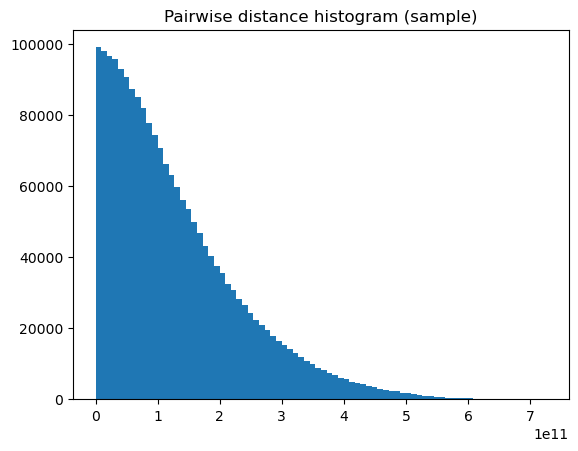

In [3]:
import numpy as np
from scipy.spatial.distance import pdist
rng = np.random.RandomState(42)
idx = rng.choice(len(coords), size=min(2000, len(coords)), replace=False)
d = pdist(coords[idx])
print("distances: min, median, mean, 90pct, max:", d.min(), np.median(d), d.mean(), np.percentile(d,90), d.max())
# optional: quick histogram
import matplotlib.pyplot as plt
plt.hist(d, bins=80); plt.title("Pairwise distance histogram (sample)"); plt.show()


In [4]:
import numpy as np, pandas as pd
df = pd.read_csv("derived/acsc_projected_cremona_ptd_aligned.csv")  # or your aligned file
coords = df[["x_ptd_al","y_ptd_al","z_ptd_al"]].to_numpy()
np.savez_compressed("derived/coords_ptd_al.npz", coords=coords)
print("Saved coords shape:", coords.shape)


Saved coords shape: (38042, 3)


In [4]:
# Batch TDA pipeline (fixed, one cell)
import os, sys, json, time, pickle, subprocess
from pathlib import Path
import numpy as np
import pandas as pd

# ---------- User-editable parameters ----------
aligned_csv = "derived/acsc_projected_cremona_ptd_aligned.csv"   # input aligned coords
coords_npz = "derived/coords_ptd_al.npz"                         # saved coords file
worker_script = "scripts/tda_worker.py"
out_dir = "derived/tda_ptd_batches"
chunk = 300                     # points per chunk (200-500 recommended)
maxdim = 1                      # compute H0/H1 only
sample_size_for_thresh = 2000   # sample size to estimate distance distribution
thresh_factor = 0.3             # thresh = median(sampled_pairwise_distances) * thresh_factor
max_workers = max(1, (os.cpu_count() or 2) - 1)  # concurrency bound
timeout_seconds = 600           # per-job timeout in seconds (10 minutes)
# ------------------------------------------------

Path("scripts").mkdir(parents=True, exist_ok=True)
Path("derived").mkdir(parents=True, exist_ok=True)
Path(out_dir).mkdir(parents=True, exist_ok=True)

# 1) Write worker script
worker_code = r'''
# scripts/tda_worker.py
import sys, json, pickle, numpy as np
from pathlib import Path
from acsc.tda_pipeline import compute_persistence

def main(coords_npz, out_dir, start, end, maxdim="1", thresh="None"):
    coords_npz = Path(coords_npz)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    data = np.load(coords_npz)
    coords = data["coords"][int(start):int(end)]
    try:
        thr = None if thresh in ("None","none","") else float(thresh)
        res = compute_persistence(coords, maxdim=int(maxdim), thresh=thr)
        out_path = out_dir / f"dgms_{start}_{end}.pkl"
        with open(out_path, "wb") as fh:
            pickle.dump(res, fh)
        print("OK", start, end, out_path)
    except Exception as e:
        err_path = out_dir / f"error_{start}_{end}.json"
        err = {"start": int(start), "end": int(end), "error": str(e)}
        err_path.write_text(json.dumps(err))
        print("ERR", start, end, err_path)

if __name__ == "__main__":
    # usage: python scripts/tda_worker.py coords.npz out_dir start end [maxdim] [thresh]
    main(*sys.argv[1:])
'''
Path(worker_script).write_text(worker_code)
print("Wrote worker script:", worker_script)

# 2) Load aligned CSV and save coords npz
if not Path(aligned_csv).exists():
    raise FileNotFoundError(f"Aligned CSV not found: {aligned_csv}")

df = pd.read_csv(aligned_csv)
if not {"x_ptd_al","y_ptd_al","z_ptd_al"}.issubset(df.columns):
    raise ValueError("Aligned CSV must contain x_ptd_al,y_ptd_al,z_ptd_al columns")

coords = df[["x_ptd_al","y_ptd_al","z_ptd_al"]].to_numpy()
np.savez_compressed(coords_npz, coords=coords)
print("Saved coords:", coords_npz, "shape:", coords.shape)

# 3) Estimate a conservative threshold from sampled pairwise distances
from scipy.spatial.distance import pdist
n = coords.shape[0]
sample_n = min(sample_size_for_thresh, n)
rng = np.random.RandomState(42)
sample_idx = rng.choice(n, size=sample_n, replace=False)
sample_coords = coords[sample_idx]
d = pdist(sample_coords)
median_d = float(np.median(d))
thresh = float(median_d * thresh_factor)
print(f"Sampled {sample_n} points; median pairwise distance {median_d:.6g}; chosen thresh {thresh:.6g}")

# 4) Build job list
jobs = []
for start in range(0, n, chunk):
    end = min(n, start + chunk)
    jobs.append({"start": int(start), "end": int(end)})

jobs_meta = {
    "coords_file": coords_npz,
    "out_dir": out_dir,
    "n_points": int(n),
    "chunk": int(chunk),
    "maxdim": int(maxdim),
    "thresh": float(thresh),
    "jobs_total": len(jobs),
    "created_at": time.time()
}
Path(out_dir, "jobs.json").write_text(json.dumps(jobs_meta, indent=2))
print("Prepared", len(jobs), "jobs; chunk size:", chunk, "max_workers:", max_workers)

# 5) Launch jobs with bounded concurrency and per-job timeout
active = []
completed = []
failed = []
job_index = 0

def launch_job(job):
    start, end = job["start"], job["end"]
    cmd = [sys.executable, worker_script, coords_npz, out_dir, str(start), str(end), str(maxdim), str(thresh)]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    return {"proc": p, "start": start, "end": end, "launched_at": time.time()}

print("Launching jobs...")
try:
    while job_index < len(jobs) or active:
        # launch while we have capacity
        while job_index < len(jobs) and len(active) < max_workers:
            job = jobs[job_index]
            handle = launch_job(job)
            active.append(handle)
            job_index += 1
            print(f"Launched job {handle['start']}:{handle['end']} (active {len(active)})")
            time.sleep(float(0.05))   # use float sleep

        # poll active processes
        for handle in active[:]:
            p = handle["proc"]
            ret = p.poll()
            elapsed = time.time() - handle["launched_at"]
            if ret is not None:
                # process finished
                try:
                    stdout, stderr = p.communicate(timeout=1)
                except Exception:
                    stdout, stderr = "", ""
                if ret == 0:
                    completed.append((int(handle['start']), int(handle['end'])))
                    print(f"Completed {handle['start']}:{handle['end']}")
                else:
                    failed.append((int(handle['start']), int(handle['end']), (stderr or "").strip()[:200]))
                    print(f"Failed {handle['start']}:{handle['end']} ret={ret} err={(stderr or '').strip()[:200]}")
                active.remove(handle)
            elif elapsed > timeout_seconds:
                # timeout: kill process
                try:
                    p.kill()
                except Exception:
                    pass
                failed.append((int(handle['start']), int(handle['end']), "timeout"))
                print(f"Timeout killed job {handle['start']}:{handle['end']}")
                active.remove(handle)
        # brief sleep to avoid busy loop
        time.sleep(float(0.5))
except KeyboardInterrupt:
    print("Interrupted by user; terminating active workers...")
    for handle in active:
        try:
            handle["proc"].kill()
        except Exception:
            pass
    raise

# helper: sanitize objects for JSON
import numpy as _np
def _to_py(obj):
    if obj is None or isinstance(obj, (str, bool, int, float)):
        return obj
    if isinstance(obj, (_np.integer, _np.floating, _np.bool_)):
        return obj.item()
    if isinstance(obj, dict):
        return {str(k): _to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_py(v) for v in obj]
    try:
        if hasattr(obj, "__int__") and not isinstance(obj, bool):
            return int(obj)
    except Exception:
        pass
    try:
        if hasattr(obj, "__float__"):
            return float(obj)
    except Exception:
        pass
    return str(obj)

def write_json_safe(path, obj, indent=2):
    Path(path).write_text(json.dumps(_to_py(obj), indent=indent))

# 6) Summary and write status (sanitized)
status = {
    "completed_count": int(len(completed)),
    "failed_count": int(len(failed)),
    "completed": completed[:20],
    "failed": failed[:20]
}
write_json_safe(Path(out_dir, "jobs_status.json"), status, indent=2)
print("All jobs processed. Completed:", len(completed), "Failed:", len(failed))

# 7) Aggregate results (load pickles)
import glob
pkl_files = sorted(glob.glob(os.path.join(out_dir, "dgms_*.pkl")))
print("Found pkl result files:", len(pkl_files))
all_results = []
for f in pkl_files:
    try:
        with open(f, "rb") as fh:
            res = pickle.load(fh)
        all_results.append(res)
    except Exception as e:
        print("Error loading", f, e)

# Example summary: print first 5 chunk diagram sizes
for i, res in enumerate(all_results[:5]):
    dgms = res.get("dgms", [])
    print(f"chunk {i} dgms lengths:", [len(d) for d in dgms])

# Save a small index manifest for downstream analysis (sanitized)
manifest = {
    "coords_file": coords_npz,
    "result_files": pkl_files,
    "n_chunks": len(pkl_files),
    "completed": len(completed),
    "failed": len(failed),
    "params": {"chunk": chunk, "max_workers": max_workers, "thresh": thresh, "maxdim": maxdim}
}
write_json_safe(Path(out_dir, "aggregate_manifest.json"), manifest, indent=2)
print("Wrote aggregate manifest:", Path(out_dir, "aggregate_manifest.json"))
print("Pipeline finished.")


Wrote worker script: scripts/tda_worker.py
Saved coords: derived/coords_ptd_al.npz shape: (38042, 3)
Sampled 2000 points; median pairwise distance 1.02455e+11; chosen thresh 3.07365e+10
Prepared 127 jobs; chunk size: 300 max_workers: 11
Launching jobs...
Launched job 0:300 (active 1)
Launched job 300:600 (active 2)
Launched job 600:900 (active 3)
Launched job 900:1200 (active 4)
Launched job 1200:1500 (active 5)
Launched job 1500:1800 (active 6)
Launched job 1800:2100 (active 7)
Launched job 2100:2400 (active 8)
Launched job 2400:2700 (active 9)
Launched job 2700:3000 (active 10)
Launched job 3000:3300 (active 11)
Completed 2400:2700
Completed 2700:3000
Completed 3000:3300
Launched job 3300:3600 (active 9)
Launched job 3600:3900 (active 10)
Launched job 3900:4200 (active 11)
Completed 900:1200
Completed 1200:1500
Completed 1500:1800
Completed 1800:2100
Completed 2100:2400
Launched job 4200:4500 (active 7)
Launched job 4500:4800 (active 8)
Launched job 4800:5100 (active 9)
Launched job 

In [5]:
# List and quick verify
from pathlib import Path
import glob, pickle, json

out_dir = Path("derived/tda_ptd_batches")
pkl_files = sorted(glob.glob(str(out_dir / "dgms_*.pkl")))
err_files = sorted(glob.glob(str(out_dir / "error_*.json")))

print("Result files:", len(pkl_files))
print("Error files:", len(err_files))
# show first and last few
print("Sample files:", pkl_files[:3], "...", pkl_files[-3:])


Result files: 127
Error files: 0
Sample files: ['derived/tda_ptd_batches/dgms_0_300.pkl', 'derived/tda_ptd_batches/dgms_10200_10500.pkl', 'derived/tda_ptd_batches/dgms_10500_10800.pkl'] ... ['derived/tda_ptd_batches/dgms_9300_9600.pkl', 'derived/tda_ptd_batches/dgms_9600_9900.pkl', 'derived/tda_ptd_batches/dgms_9900_10200.pkl']


In [9]:
# sanitize_and_write_summary.py
import json, numpy as np
from pathlib import Path

def _to_py(obj):
    # Convert numpy scalars, SymPy-like wrappers, and nested containers to plain Python types
    if obj is None or isinstance(obj, (str, bool, int, float)):
        return obj
    if isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()
    if isinstance(obj, dict):
        return {str(k): _to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_py(v) for v in obj]
    # Try numeric coercions for wrappers exposing __int__/__float__
    try:
        if hasattr(obj, "__int__") and not isinstance(obj, bool):
            return int(obj)
    except Exception:
        pass
    try:
        if hasattr(obj, "__float__"):
            return float(obj)
    except Exception:
        pass
    # Fallback to string
    return str(obj)

# Load summaries from memory if present, otherwise reconstruct from all_results
try:
    summaries  # use existing variable if in notebook namespace
except NameError:
    # attempt to reconstruct minimal summaries from pickles
    import glob, pickle
    files = sorted(glob.glob("derived/tda_ptd_batches/dgms_*.pkl"))
    summaries = []
    for f in files:
        with open(f, "rb") as fh:
            res = pickle.load(fh)
        dgms = res.get("dgms", [])
        h0 = np.asarray(dgms[0]) if len(dgms) > 0 else np.empty((0,2))
        h1 = np.asarray(dgms[1]) if len(dgms) > 1 else np.empty((0,2))
        summaries.append({
            "file": f,
            "n_h0": int(len(h0)),
            "n_h1": int(len(h1)),
            "h0_mean_life": float(np.mean(h0[:,1]-h0[:,0])) if h0.size else 0.0,
            "h1_mean_life": float(np.mean(h1[:,1]-h1[:,0])) if h1.size else 0.0
        })

out_path = Path("derived/tda_ptd_batches/summary_per_chunk.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(_to_py(summaries), indent=2))
print("Wrote sanitized summary to", out_path)


Wrote sanitized summary to derived/tda_ptd_batches/summary_per_chunk.json


In [10]:
# quick verify
import json
p = "derived/tda_ptd_batches/summary_per_chunk.json"
s = json.loads(open(p).read())
print("Chunks in summary:", len(s))
print("Example entry:", s[0])


Chunks in summary: 127
Example entry: {'file': 'derived/tda_ptd_batches/dgms_0_300.pkl', 'n_h0': 746, 'n_h1': 0, 'h0_mean_life': inf, 'h1_mean_life': 0}


In [13]:
import json, re, time
from pathlib import Path
import numpy as np
import pandas as pd

RAW_CSV = "cremona_raw_parsed.csv"          # or lmfdb_raw_parsed.csv
CLEAN_CSV = "acsc_validation_cremona.csv"   # output
MANIFEST = CLEAN_CSV.replace(".csv", ".manifest.json")

# canonical column mapping
CANONICAL = {
    "delta": ["delta","minimal_discriminant","disc","D","discriminant"],
    "conductor": ["conductor","N","cond","label"],
    "rank": ["sage_rank","rank","algebraic_rank","pari_analytic_rank"],
    "regulator": ["regulator","R"],
    "real_period": ["real_period","omega_real","Q"],
    "torsion_order": ["torsion_order","torsion","T"],
}

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def extract_conductor_from_label(label):
    if pd.isna(label):
        return None
    s = str(label).strip()
    m = re.match(r"^\s*(\d+)", s)
    if m:
        return int(m.group(1))
    m = re.match(r"^(\d+)\.", s)
    if m:
        return int(m.group(1))
    return None

def normalize_and_clean_df(df):
    col_matches = {k: find_col(df, v) for k,v in CANONICAL.items()}
    out = pd.DataFrame(index=df.index)

    # fill canonical columns
    for key, col in col_matches.items():
        out[key] = df[col] if col is not None else np.nan

    # conductor fallback
    if col_matches.get("conductor") is None and "label" in df.columns:
        out["conductor"] = df["label"].apply(extract_conductor_from_label)

    # numeric coercion
    for c in ["delta","conductor","rank","regulator","real_period","torsion_order"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # keep label + source if present
    for extra in ["label","source"]:
        if extra in df.columns:
            out[extra] = df[extra]

    diag = {
        "rows_total": int(len(df)),
        "col_matches": col_matches,
        "null_counts": {k:int(v) for k,v in out.isna().sum().to_dict().items()}
    }
    return out, diag

def reprocess_file(infile, outfile, manifest_path):
    infile = Path(infile)
    outfile = Path(outfile)
    manifest_path = Path(manifest_path)

    df = pd.read_csv(infile)
    cleaned, diag = normalize_and_clean_df(df)

    # ACSC policy: require delta + rank
    mask = cleaned["delta"].notna() & cleaned["rank"].notna()
    kept = cleaned[mask].copy()

    kept.to_csv(outfile, index=False)

    manifest = {
        "input_file": str(infile),
        "output_file": str(outfile),
        "rows_input": int(len(df)),
        "rows_output": int(len(kept)),
        "diagnostics": diag,
        "drop_policy": "drop rows missing delta or rank",
        "timestamp": time.time()
    }
    manifest_path.write_text(json.dumps(manifest, indent=2))
    print(f"Wrote cleaned CSV {outfile} rows_out={len(kept)}")
    return kept, manifest

clean_df, manifest = reprocess_file(RAW_CSV, CLEAN_CSV, MANIFEST)
clean_df.head()

from acsc.projection import project as project_primary
from acsc.alt_mappings import map_ptd, map_mcj

records = clean_df.to_dict(orient="records")

coords_primary = project_primary(records, method="primary", Amax=1.0, Nmax=1.0, V0=1.0)
coords_ptd     = map_ptd(records, Amax=1.0, Nmax=1.0, V0=1.0)
coords_mcj     = map_mcj(records, Amax=1.0, Nmax=1.0, V0=1.0)

clean_df[["x_prim","y_prim","z_prim"]] = coords_primary
clean_df[["x_ptd","y_ptd","z_ptd"]] = coords_ptd
clean_df[["x_mcj","y_mcj","z_mcj"]] = coords_mcj

clean_df.to_csv("derived/acsc_projected_cremona.csv", index=False)
print("Wrote derived/acsc_projected_cremona.csv")

from acsc.quantile import QuantileAligner

aligner = QuantileAligner()
ref = clean_df[["x_prim","y_prim","z_prim"]].sample(5000, random_state=int(42)).to_numpy()
aligner.fit(ref, n_quantiles=200)

aligned = aligner.transform(clean_df[["x_prim","y_prim","z_prim"]].to_numpy())
clean_df[["x_al","y_al","z_al"]] = aligned

clean_df.to_csv("derived/acsc_projected_cremona_aligned.csv", index=False)
print("Wrote aligned projection")

print("Rows:", len(clean_df))
print("Null counts:", clean_df.isna().sum().to_dict())
print("Conductor range:", clean_df["conductor"].min(), clean_df["conductor"].max())
print("Delta range:", clean_df["delta"].min(), clean_df["delta"].max())
clean_df.sample(5, random_state=int(42))


Wrote cleaned CSV acsc_validation_cremona.csv rows_out=38042
Wrote derived/acsc_projected_cremona.csv
Wrote aligned projection
Rows: 38042
Null counts: {'delta': 0, 'conductor': 0, 'rank': 0, 'regulator': 38042, 'real_period': 38042, 'torsion_order': 38042, 'label': 0, 'x_prim': 0, 'y_prim': 0, 'z_prim': 0, 'x_ptd': 0, 'y_ptd': 0, 'z_ptd': 0, 'x_mcj': 0, 'y_mcj': 0, 'z_mcj': 0, 'x_al': 0, 'y_al': 0, 'z_al': 0}
Conductor range: 11 9999
Delta range: -1.5120300338084937e+35 1.14400216043008e+31


,delta,conductor,rank,regulator,real_period,torsion_order,label,x_prim,y_prim,z_prim,x_ptd,y_ptd,z_ptd,x_mcj,y_mcj,z_mcj,x_al,y_al,z_al
37705,-7.936000e+07,9920,1,NaN,NaN,NaN,9920bd1,0.188371,0.998836,0.5,0.188371,0.5,0.0,0.998836,0.5,0.5,0.188371,0.998836,0.5
30793,-7.430400e+04,8256,1,NaN,NaN,NaN,8256s1,0.098265,0.971883,0.5,0.098265,0.5,0.0,0.971883,0.5,0.5,0.098265,0.971883,0.5
24337,-1.446181e+13,6682,0,NaN,NaN,NaN,6682c1,0.344884,0.940833,0.0,0.344884,0.5,0.0,0.940833,0.5,0.5,0.344884,0.940833,0.0
10087,5.298245e+10,3158,0,NaN,NaN,NaN,3158a1,0.272406,0.830815,0.0,0.272406,0.5,0.0,0.830815,0.5,0.5,0.272406,0.830815,0.0
8596,8.217000e+03,2739,0,NaN,NaN,NaN,2739c1,0.069813,0.809920,0.0,0.069813,0.5,0.0,0.809920,0.5,0.5,0.069813,0.809920,0.0
